## Cloning the repo

In [1]:
!git clone https://github.com/KayTheCoder-101/urdu-question-generator-.git
%cd urdu-question-generator-

Cloning into 'urdu-question-generator-'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 165 (delta 80), reused 118 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 7.09 MiB | 9.96 MiB/s, done.
Resolving deltas: 100% (80/80), done.
/content/urdu-question-generator-


## Imports

In [2]:
!pip install datasets sentencepiece sacrebleu rouge-score matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.0 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=35733e01c71c14547b5362c25db990b61b3ba5e9a82fbb6f685a3e613545afb2
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


## Checking available device

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [4]:
!ls

app.py	    decode.py		  model.py	  requirements.txt  tokenizer
data	    evaluate.py		  notebook.ipynb  results	    train.py
dataset.py  medium_blog_draft.md  README.md	  tes_tokenizer.py


## Pull any latest changes if any in train.py

In [5]:
!git pull

Already up to date.


## Loading the data

In [6]:
!python3 data/prepare_data.py

README.md: 100% 898/898 [00:00<00:00, 5.26MB/s]

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:  71% 21.6M/30.2M [00:00<00:00, 35.5MB/s,  928kB/s  ]
data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes: 100% 27.9M/27.9M [00:01<00:00, 27.5MB/s, 2.69MB/s  ]
data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file: 100% 30.2M/30.2M [00:01<00:00, 29.8MB/s, 2.94MB/s  ]

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:   3% 95.8k/2.92M [00:00<00:15, 180kB/s]
data/validation-00000-of-00001-cf8a6960d(…): downloading bytes: 100% 2.56M/2.56M [00:00<00:00, 4.58MB/s,  252kB/s  ]
data/validation-00000-of-00001-cf8a6960d(…): reconstructing file: 100% 2.92M/2.92M [00:00<00:00, 5.24MB/s,  289kB/s  ]
Generating train split: 100% 124745/124745 [00:00<00:00, 183835.70 examples/s]
Generating validation split: 100% 16824/16824 [00:00<00:00, 299165.10 examples/s]
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_

## Training

In [7]:
!python3 train.py

Epoch Number: 1
avg training loss 5.758242207989351
avg validation loss 6.167757669072242
New best model saved!
Epoch Number: 2
avg training loss 5.237730885121603
avg validation loss 6.166610350274736
New best model saved!
Epoch Number: 3
avg training loss 5.039876308050578
avg validation loss 6.091237153217292
New best model saved!
Epoch Number: 4
avg training loss 4.906617792800018
avg validation loss 6.061914377151781
New best model saved!
Epoch Number: 5
avg training loss 4.800964890079694
avg validation loss 6.03715804276193
New best model saved!
Epoch Number: 6
avg training loss 4.679794200858159
avg validation loss 6.038111167348874
No improvement. Patience: 1/3
Epoch Number: 7
avg training loss 4.590212572149856
avg validation loss 5.925365262730106
New best model saved!
Epoch Number: 8
avg training loss 4.501563013820518
avg validation loss 5.939192908584692
No improvement. Patience: 1/3
Epoch Number: 9
avg training loss 4.402339196652682
avg validation loss 5.876446945652081

## checking if the model is saved

In [8]:
!ls -lh best_model.pt

-rw-r--r-- 1 root root 96M Sep 12 09:36 best_model.pt


### mounting to the google drive saving the file on your drive can delete later 90 MB file

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('best_model.pt', '/content/drive/MyDrive/best_model.pt')

Mounted at /content/drive


'/content/drive/MyDrive/best_model.pt'

## move to your vscode

In [ ]:
mv ~/Downloads/best_model.pt ~/urdu-question-generation/

mv: cannot stat '/root/Downloads/best_model.pt': No such file or directory


## plotting the loss curves

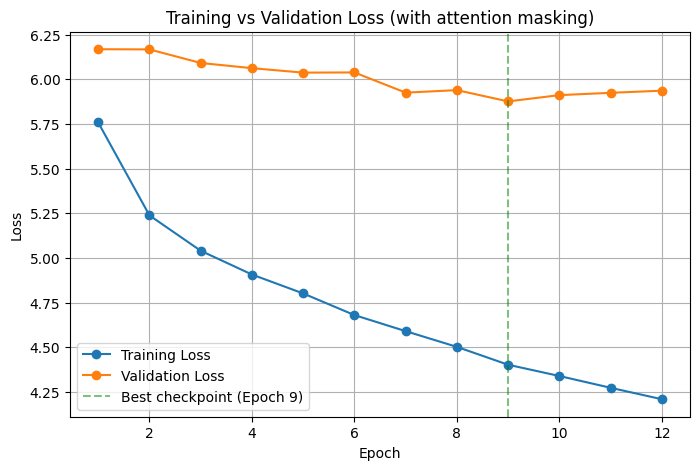

In [10]:
import matplotlib.pyplot as plt

train_losses = [5.758, 5.238, 5.040, 4.907, 4.801, 4.680, 4.590, 4.502, 4.402, 4.339, 4.273, 4.209]
valid_losses = [6.168, 6.167, 6.091, 6.062, 6.037, 6.038, 5.925, 5.939, 5.876, 5.911, 5.924, 5.936]

epochs = range(1, 13)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Training Loss", marker='o')
plt.plot(epochs, valid_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (with attention masking)")
plt.legend()
plt.grid(True)

# Mark the best checkpoint (Epoch 9)
plt.axvline(x=9, color='green', linestyle='--', alpha=0.5, label="Best checkpoint (Epoch 9)")
plt.legend()

plt.savefig("results/loss.png")
plt.show()

In [13]:
!git config --global user.name "KayTheCoder-101"
!git config --global user.email "kulsoomume362@gmail.com"

In [14]:
!git add notebook.ipynb results/loss.png
!git commit -m "Update loss curve with final training run"
!git push https://YOUR_TOKEN@github.com/KayTheCoder-101/urdu-question-generator-.git main

[main b92d2f9] Update loss curve with final training run
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 results/loss.png
fatal: could not read Password for 'https://YOUR_TOKEN@github.com': No such device or address
